# Cross-survey embedding visualization — COSMOS ∩ OutThere

The OutThere `sex-*` NIRISS fields overlap the COSMOS-Web NIRCam field, so ~8.7k objects are
imaged by **both** surveys. We embed each object's cutout from *each* survey with the frozen
jwst_dino teacher and visualize:

1. **paired vs random cosine similarity** — does the same physical object embed near itself
   across the NIRCam↔NIRISS / depth domain gap?
2. **2D projection coloured by survey** — do the two surveys mix, or does domain dominate?
3. **2D projection coloured by COSMOS morphology** — does morphology structure survive?

In [37]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings; warnings.simplefilter('ignore')

sys.path.insert(0, os.path.join('..', '..'))        # jwst_dino/ (model import)
from model.jwst_dino import load_teacher_backbone
from crossmatch import crossmatch_indices, CutoutDataset, extract_embeddings
from dataset import CLASS_NAMES

ROOT   = '~/ssl_outthere/data/image'
CKPT   = '/home/yacheng/ssl_outthere/encoder_image/jwst_dino/outputs/jwst_dino_ps6_st3/version_3/checkpoints/epoch=epoch=179-step=step=90000.ckpt'
MORPH  = '../../../../data/survey/cosmos_2025/COSMOSWeb_mastercatalog_v1_ml_morph.fits'
TOL    = 0.5      # cross-match radius [arcsec]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cuda


In [38]:
# 1) cross-match the two surveys (row-aligned: row i = same object in both)
cos, out = crossmatch_indices(ROOT, 'cosmos', 'outthere', tol_arcsec=TOL)
print(f'{len(cos)} common objects  (median sep {np.median(cos["sep_arcsec"]):.3f}")')
tiles, cnts = np.unique(out['tile'], return_counts=True)
print('OutThere fields:', dict(zip(tiles.tolist(), cnts.tolist())))

8668 common objects  (median sep 0.047")
OutThere fields: {'sex-06': 1336, 'sex-07': 1183, 'sex-08': 1186, 'sex-09': 3057, 'sex-10': 2, 'sex-16': 1904}


In [39]:
# 2) load the frozen teacher, embed each side (COSMOS NIRCam cutout & OutThere NIRISS cutout)
net = load_teacher_backbone(CKPT, DEVICE); crop = net.crop_size
E_cos = extract_embeddings(net, CutoutDataset(ROOT, cos, crop_size=crop), DEVICE)
E_out = extract_embeddings(net, CutoutDataset(ROOT, out, crop_size=crop), DEVICE)
print('embeddings:', E_cos.shape, E_out.shape)

# COSMOS morphology label for each matched object (id = master-catalog row index)
mm = fits.open(os.path.expanduser(MORPH), memmap=True)[1].data
morph = np.asarray(mm['morph_flag_f150w'])[np.asarray(cos['id'])]

# drop irregular (class 2) & unclassified — we don't care about irregulars
keep = (morph != 999999) & (morph != 2)
cos, out = cos[keep], out[keep]
E_cos, E_out, morph = E_cos[keep], E_out[keep], morph[keep]
print(f'kept {int(keep.sum())} non-irregular classified objects (sph/disk/bd)')

embeddings:   0%|          | 0/34 [00:00<?, ?it/s]

embeddings:   0%|          | 0/34 [00:00<?, ?it/s]

embeddings: (8668, 512) (8668, 512)
kept 677 non-irregular classified objects (sph/disk/bd)


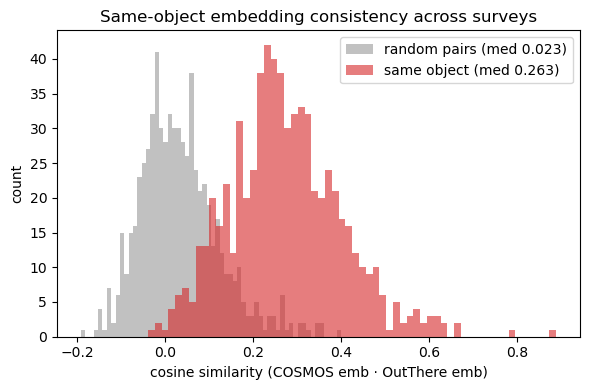

In [40]:
# 3) paired vs random cosine similarity — same object across surveys vs chance
from sklearn.preprocessing import normalize
na, nb = normalize(E_cos), normalize(E_out)
paired = (na * nb).sum(1)
rng = np.random.default_rng(0)
rand = (na * nb[rng.permutation(len(nb))]).sum(1)

plt.figure(figsize=(6, 4))
plt.hist(rand,   bins=60, alpha=0.6, label=f'random pairs (med {np.median(rand):.3f})', color='#999')
plt.hist(paired, bins=60, alpha=0.6, label=f'same object (med {np.median(paired):.3f})', color='#d62728')
plt.xlabel('cosine similarity (COSMOS emb · OutThere emb)'); plt.ylabel('count')
plt.title('Same-object embedding consistency across surveys'); plt.legend(); plt.tight_layout(); plt.show()

In [41]:
# 4) joint 2D projection (PCA-50 -> t-SNE) of both surveys' embeddings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

N = min(2500, len(E_cos))                      # subsample for t-SNE speed
sel = rng.choice(len(E_cos), size=N, replace=False)
X = np.concatenate([E_cos[sel], E_out[sel]])    # stack both surveys
survey = np.array([0]*N + [1]*N)                # 0=COSMOS, 1=OutThere
morph_s = np.concatenate([morph[sel], morph[sel]])

Xp = PCA(n_components=50, random_state=0).fit_transform(X)
Z  = TSNE(n_components=2, perplexity=30, init='pca', random_state=0).fit_transform(Xp)
print('projected', Z.shape)

projected (1354, 2)


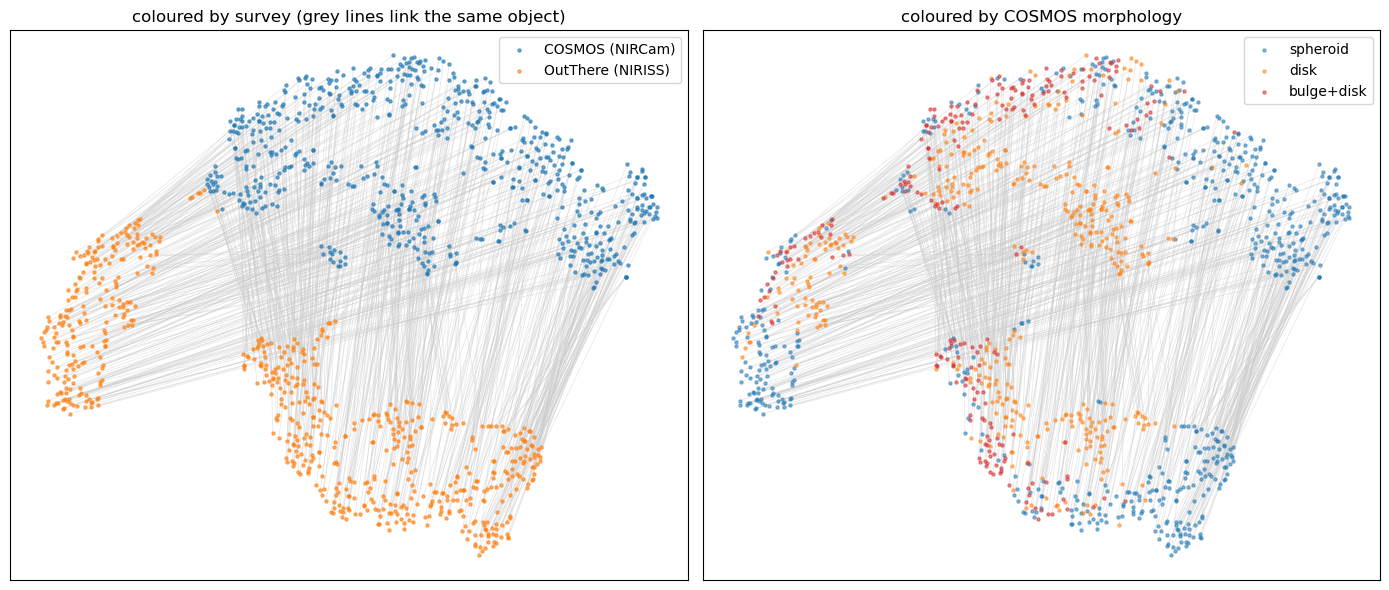

In [43]:

# colour by survey (left, with faint same-object links) and by COSMOS morphology (right)
from matplotlib.collections import LineCollection
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# faint lines linking each object's COSMOS <-> OutThere embedding (rows i and N+i = same object)
segs = np.stack([Z[:N], Z[N:]], axis=1)        # (N, 2, 2)
ax[0].add_collection(LineCollection(segs, colors='#cccccc', linewidths=0.5, alpha=0.5, zorder=0))
for s, c, name in [(0, '#1f77b4', 'COSMOS (NIRCam)'), (1, '#ff7f0e', 'OutThere (NIRISS)')]:
    m = survey == s
    ax[0].scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.6, color=c, label=name, zorder=2)
ax[0].set_title('coloured by survey (grey lines link the same object)')
ax[0].legend(); ax[0].set_xticks([]); ax[0].set_yticks([])

valid = morph_s != 999999
cmap = plt.get_cmap('tab10')
for k in sorted(set(morph_s[valid].tolist())):
    m = valid & (morph_s == k)
    ax[1].scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.5, color=cmap(k), label=CLASS_NAMES.get(k, k))
#also plot the connecting lines for the morphology-coloured plot
segs = np.stack([Z[:N][valid[:N]], Z[N:][valid[N:]]], axis=1)        # (N, 2, 2)
ax[1].add_collection(LineCollection(segs, colors='#cccccc', linewidths=0.5, alpha=0.5, zorder=0))

ax[1].set_title('coloured by COSMOS morphology'); ax[1].legend(); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.savefig('crossmatch_embeddings.png', dpi=110); plt.show()